## Transfer Learning for Computer Vision Tutorial
- CNN

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from pytorch_tutorial import setup_japanese_font

cudnn.benchmark = True
plt.ion()   # interactive mode

In [2]:
# データの読み込みと前処理
data_transforms = {
    'train': transforms.Compose([
        # 画像をランダムにキリトリ、リサイズ
        transforms.RandomResizedCrop(224),
        # 画像を水平に反転
        transforms.RandomHorizontalFlip(),
        # 画像をTensorに変換
        transforms.ToTensor(),
        # 画像を標準化
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        # 画像をランダムにキリトリ、リサイズ
        transforms.Resize(256),
        # 画像を中心でクロップ
        transforms.CenterCrop(224),
        # 画像をTensorに変換
        transforms.ToTensor(),
        # 画像を標準化
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/share/dtu_drone_tutorial/hymenoptera_data'
# trainとvalを辞書型を用いて使い分け
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
                  
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# gpuを使用できるか確認。できない場合は、cpuを使用
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(f"Using {device} device")

Using cuda device


In [ ]:
# 検証データの数を確認
print(len(image_datasets['val']))
# 検証データのクラス名を確認
print(len(image_datasets['train']))

In [ ]:
print(class_names)

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    # テンソル型とnumpy型では、channelの位置が異なる
    inp = inp.numpy().transpose((1, 2, 0))
    # 標準化の逆操作
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated
    return inp


# データをバッチ単位で一つ取ってくる
inputs, classes = next(iter(dataloaders['train']))
print(inputs.shape, classes.shape)

# 画像を横に並べる
out = torchvision.utils.make_grid(inputs)
print(out.shape) # <= (3, 228, 906) = (3, 224+2*2, 224*4+2*(4+1))

# imshow(out, title=[class_names[x] for x in classes])

torch.Size([4, 3, 224, 224]) torch.Size([4])
torch.Size([3, 228, 906])


In [4]:
def train_model(model, criterion, optimizer, scheduler, store_log:dict, num_epochs=25):
    since = time.time()

    # 一時的なパラメータ保存ディレクトリを作成
    # with文のスコープを抜けると、一時的なディレクトリが自動的に削除される
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        # print(best_model_params_path)

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # 1エポック毎にtrainとvalを実行する
            for phase in ['train', 'val']:
                # gpuメモリのリセット
                torch.cuda.reset_peak_memory_stats()
                torch.cuda.empty_cache()
                print(torch.cuda.memory_stats())

                if phase == 'train':
                    model.train()  # trainモードにする
                else:
                    model.eval()   # evalモードにする

                running_loss = 0.0
                running_corrects = 0

                epoch_time = 0
                # イテレーションループ
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # 勾配情報を0にする(残っている勾配をリセット)
                    optimizer.zero_grad()

                    # モデルに入力を与えて、出力を得る
                    with torch.set_grad_enabled(phase == 'train'):
                        s_time = time.time()
                        outputs = model(inputs)

                        _, preds = torch.max(outputs, dim=1)
                        loss = criterion(outputs, labels)

                        # trainの時、逆誤差伝搬と最適化
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                        
                        epoch_time += time.time() - s_time

                    # 損失関数の値を計算する
                    running_loss += loss.item() * inputs.size(0)
                    # 正解数を計算する
                    running_corrects += torch.sum(preds == labels.data)

                # 学習の時は、学習率をschedulerで更新する
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # 未学習の検証データでの正答率が一番高い時のモデルを保存
                # 訓練データの過学習を防ぐ役割がある
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

                # GPU記録
                gpu_memory_usage = torch.cuda.memory_stats()['active_bytes.all.peak'] / 1024**2
                gpu_memory_usage_reserved = torch.cuda.memory_stats()['reserved_bytes.all.peak'] / 1024**2
                
                # ログを保存
                store_log[phase]['loss'].append(epoch_loss)
                store_log[phase]['acc'].append(epoch_acc.item())
                store_log[phase]['time'].append(epoch_time)
                store_log[phase]['gpus_allocated'].append(gpu_memory_usage)
                store_log[phase]['gpus_reserved'].append(gpu_memory_usage_reserved)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # 一番ベストなモデルのパラメータを読み込む
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [5]:
# 未学習の検証データの画像でモデルの出力を可視化する
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    # モデル内のパラメータの勾配を計算しないようにセット
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            # labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}, correct: {class_names[labels[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [35]:
# モデルのパラメータ
lr = 0.0005
momentum = 0.95
step_size = 7
gamma = 0.15

### パラメータ固定を行わず処理

In [6]:
# resnet18の事前学習済みパラメータを使用する
model_ft = models.resnet18(weights='IMAGENET1K_V1')
# モデルの最後の全結合層の入力数を取得
num_ftrs = model_ft.fc.in_features

# print(model_ft)
# print(num_ftrs)

In [36]:
# モデルの出力数(分類するクラス数)を変更する(出力値を1000 -> 2に変更)
model_ft.fc = nn.Linear(num_ftrs, 2)
model_ft = model_ft.to(device)

# 損失関数を設定する
criterion = nn.CrossEntropyLoss()

# 最適化アルゴリズムを設定する
optimizer_ft = optim.SGD(model_ft.parameters(), lr=lr, momentum=momentum)

# 学習率を7エポックごとに0.1倍にする
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=step_size, gamma=gamma)

In [37]:
model_ft_logs = {'train': {'loss': [], 'acc': [], 'time': [], 'gpus_allocated': [], 'gpus_reserved': []},
             'val': {'loss': [], 'acc': [], 'time': [], 'gpus_allocated': [], 'gpus_reserved': []}}
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       store_log=model_ft_logs,
                       num_epochs=25)

Epoch 0/24
----------
OrderedDict([('active.all.allocated', 2937795), ('active.all.current', 248), ('active.all.freed', 2937547), ('active.all.peak', 248), ('active.large_pool.allocated', 1130081), ('active.large_pool.current', 18), ('active.large_pool.freed', 1130063), ('active.large_pool.peak', 18), ('active.small_pool.allocated', 1807714), ('active.small_pool.current', 230), ('active.small_pool.freed', 1807484), ('active.small_pool.peak', 230), ('active_bytes.all.allocated', 5469947018240), ('active_bytes.all.current', 108572160), ('active_bytes.all.freed', 5469838446080), ('active_bytes.all.peak', 108572160), ('active_bytes.large_pool.allocated', 5040523443712), ('active_bytes.large_pool.current', 101613568), ('active_bytes.large_pool.freed', 5040421830144), ('active_bytes.large_pool.peak', 101613568), ('active_bytes.small_pool.allocated', 429423574528), ('active_bytes.small_pool.current', 6958592), ('active_bytes.small_pool.freed', 429416615936), ('active_bytes.small_pool.peak', 6

In [ ]:
visualize_model(model_ft)

In [53]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
# 畳み込み層の箇所のパラメータを固定して学習する(勾配計算を行わない)
for param in model_conv.parameters():
    param.requires_grad = False

# モデルの出力数(分類するクラス数)を変更する(出力値を1000 -> 2に変更)
# 新しく作成されたモジュールはデフォルトで、勾配計算Trueとなっている。
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

# loss計算をセット
criterion = nn.CrossEntropyLoss()

# 最適化アルゴリズムを設定する
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.0005, momentum=0.8)

# 学習率を7エポックごとに0.1倍にする
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=10, gamma=0.1)

In [54]:
model_conv_logs = {'train': {'loss': [], 'acc': [], 'time': [], 'gpus_allocated': [], 'gpus_reserved': []},
             'val': {'loss': [], 'acc': [], 'time': [], 'gpus_allocated': [], 'gpus_reserved': []}} 
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, store_log=model_conv_logs, num_epochs=25)

Epoch 0/24
----------
OrderedDict([('active.all.allocated', 4419460), ('active.all.current', 308), ('active.all.freed', 4419152), ('active.all.peak', 308), ('active.large_pool.allocated', 1673944), ('active.large_pool.current', 26), ('active.large_pool.freed', 1673918), ('active.large_pool.peak', 26), ('active.small_pool.allocated', 2745516), ('active.small_pool.current', 282), ('active.small_pool.freed', 2745234), ('active.small_pool.peak', 282), ('active_bytes.all.allocated', 8038999687168), ('active_bytes.all.current', 155902464), ('active_bytes.all.freed', 8038843784704), ('active_bytes.all.peak', 155902464), ('active_bytes.large_pool.allocated', 7390429277696), ('active_bytes.large_pool.current', 145522688), ('active_bytes.large_pool.freed', 7390283755008), ('active_bytes.large_pool.peak', 145522688), ('active_bytes.small_pool.allocated', 648570409472), ('active_bytes.small_pool.current', 10379776), ('active_bytes.small_pool.freed', 648560029696), ('active_bytes.small_pool.peak', 

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [ ]:
# 一枚の画像でモデルの出力を可視化する
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        view_image = imshow(img.cpu().data[0])

        model.train(mode=was_training)

In [ ]:
visualize_model_predictions(
    model_conv,
    # model_ft,
    img_path='/share/dtu_drone_tutorial/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

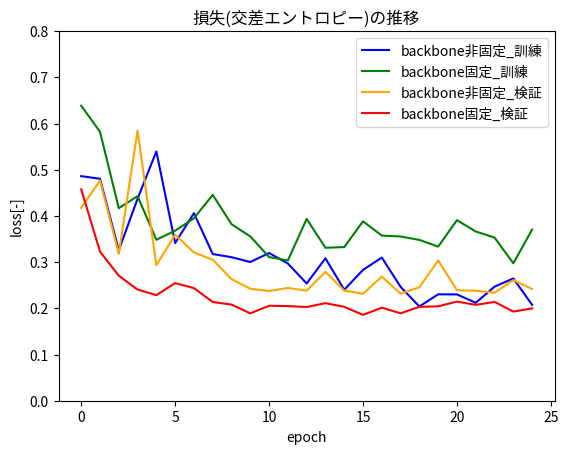

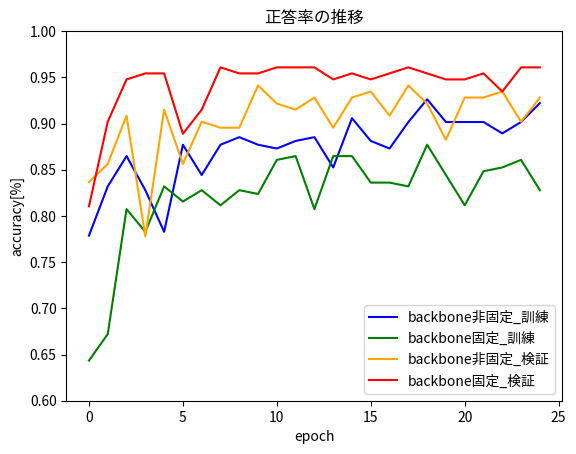

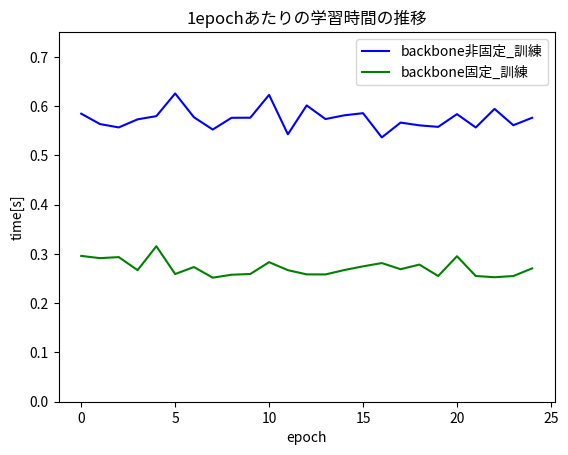

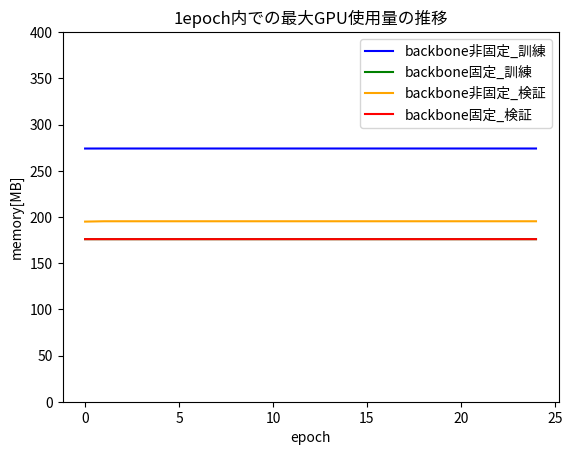

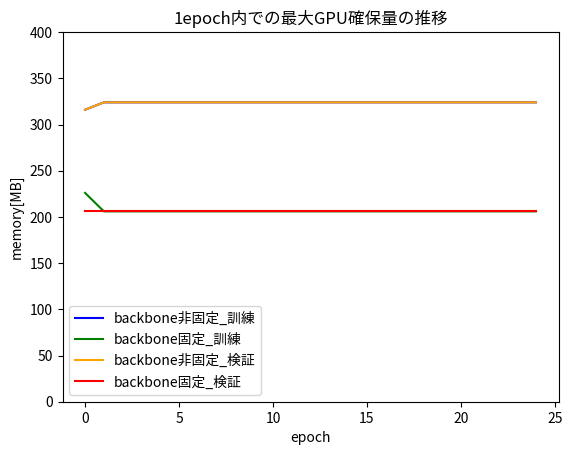

In [57]:
# 可視化グラフの作成
color_set = ['blue', 'orange', 'green', 'red']
label_set = ['backbone非固定_訓練', 'backbone非固定_検証', 'backbone固定_訓練', 'backbone固定_検証']
type_set = ['train', 'val']
value_set = ['loss', 'acc', 'time', 'gpus_allocated', 'gpus_reserved']
title_set = ['損失(交差エントロピー)の推移', '正答率の推移', '1epochあたりの学習時間の推移', '1epoch内での最大GPU使用量の推移', '1epoch内での最大GPU確保量の推移']
ylabel_set = ['loss[-]', 'accuracy[%]', 'time[s]', 'memory[MB]', 'memory[MB]']
ylim_set = [(0, 0.8), (0.6, 1), (0, 0.75), (0, 400), (0, 400)]

# loss, 正解率, time, gpu使用量, gpu確保量, 
for i in range(len(value_set)):
    for j in range(len(type_set)):
        if value_set[i] == 'time' and j == 1:
            continue
        plt.plot(model_ft_logs[type_set[j]][value_set[i]], label=label_set[j], color=color_set[j])
        plt.plot(model_conv_logs[type_set[j]][value_set[i]], label=label_set[j+2], color=color_set[j+2])

    plt.title(title_set[i]) 
    plt.ylim(ylim_set[i])    
    plt.xlabel('epoch')
    plt.ylabel(ylabel_set[i])
    plt.legend()
    plt.savefig(f'./images/transferlearning/{title_set[i]}.png')
    plt.show()


In [58]:
print(max(model_ft_logs['train']['gpus_allocated']), '青')
print(max(model_ft_logs['val']['gpus_allocated']), '黄')
print(max(model_conv_logs['train']['gpus_allocated']), '緑')
print(max(model_conv_logs['val']['gpus_allocated']), '赤')

print()

print(max(model_ft_logs['train']['gpus_reserved']), '青')
print(max(model_conv_logs['train']['gpus_reserved']), '緑')
print(max(model_conv_logs['val']['gpus_reserved']), '赤')
print(max(model_ft_logs['val']['gpus_reserved']), '黄')

274.04541015625 青
195.29931640625 黄
175.939453125 緑
175.9384765625 赤

324.0 青
226.0 緑
206.0 赤
324.0 黄


In [59]:
# モデルの保存
# ベンチマークnot 固定
torch.save(model_ft.state_dict(), './models/model_ft_not_fixed.pth')
# ベンチマーク固定
torch.save(model_conv.state_dict(), './models/model_conv_fixed.pth')